In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
L = 256

# Point Operation

## Log Transformation

$$
s = c \log(1+r)
$$

Let $r$ be the input pixel value limited to the range $[0, 255]$, and $s$ be the output pixel value. $c$ is a constant that scales the output to the range $[0, 255]$. The log transformation can be used to expand the values of dark pixels in an image while compressing the higher-level values.

$$
\begin{aligned}
255 &= c \log(1+255) \\
c &= \frac{255}{\log(256)} \\
\end{aligned}
$$

In [3]:
c = (L-1)/np.log(L)

def log_transform(r):
    return c*np.log(1+r)

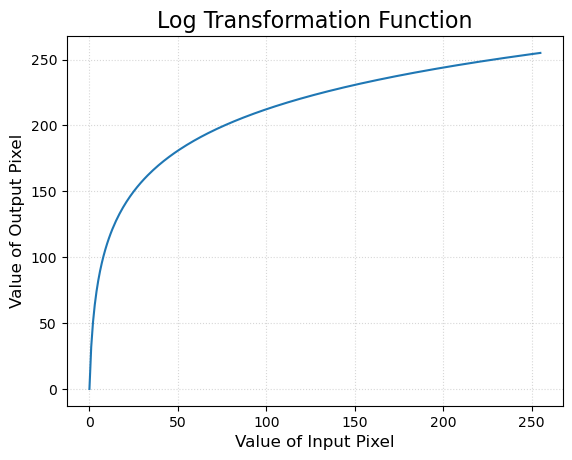

In [4]:
x = range(L)
y = [log_transform(r) for r in x]
plt.plot(x, y)
plt.xlabel('Value of Input Pixel', fontsize=12)
plt.ylabel('Value of Output Pixel', fontsize=12)
plt.title('Log Transformation Function', fontsize=16)
plt.grid(alpha=0.5, linestyle=':')
# plt.show()
plt.savefig("../../img/image-processing/log_transformation.png", dpi=300, bbox_inches='tight')

## Gamma Transformation

$$
s = cr^\gamma
$$

$c$ is a constant that scales the output to the range $[0, 255]$. $\gamma$ is a constant that controls the shape of the curve. When $\gamma < 1$, the image is brighter. When $\gamma > 1$, the image is darker.

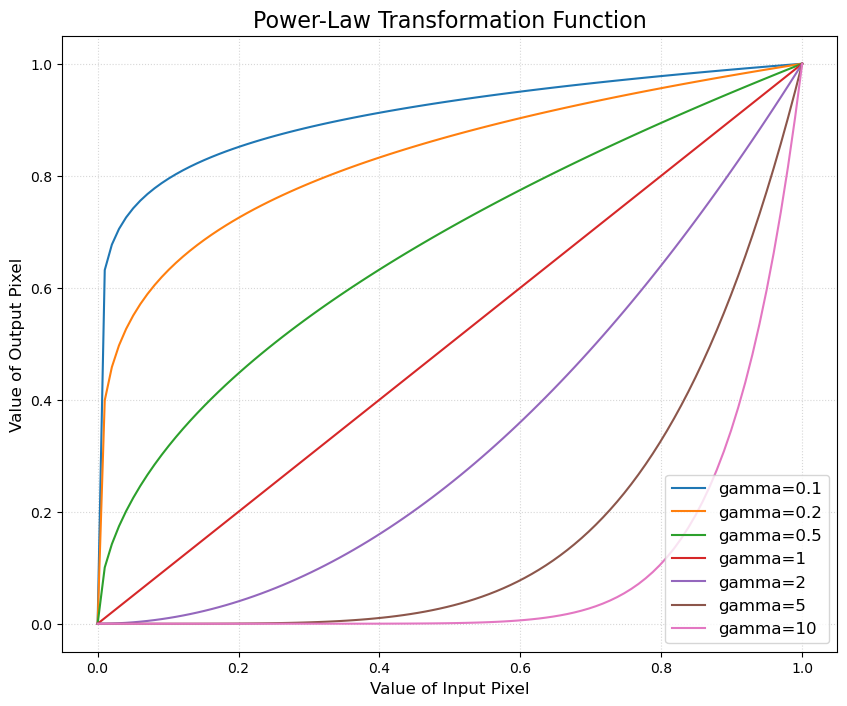

In [11]:
x = np.linspace(0, 1, 100)
gamma = [0.1, 0.2, 0.5, 1, 2, 5, 10]
plt.figure(figsize=(10,8))
for g in gamma:
    y = x**g
    plt.plot(x, y, label='gamma={}'.format(g))
plt.legend(fontsize=12)
plt.xlabel('Value of Input Pixel', fontsize=12)
plt.ylabel('Value of Output Pixel', fontsize=12)
plt.title('Power-Law Transformation Function', fontsize=16)
plt.grid(alpha=0.5, linestyle=':')
plt.savefig("../../img/image-processing/power_law_transformation.png", dpi=300, bbox_inches='tight')

In [9]:
string = "ABAACCAACB"
from collections import Counter
probs = Counter(string)
probs = {k: v / len(string) for k, v in probs.items()}
left = 0
intervals = {}
for k in probs:
    intervals[k] = (left, left + probs[k])
    left += probs[k]
intervals

{'A': (0, 0.5), 'B': (0.5, 0.7), 'C': (0.7, 1.0)}

In [20]:
def arithmetic_encode(string):

    probs = Counter(string)
    probs = {k: v / len(string) for k, v in probs.items()}
    left = 0
    intervals = {}
    for k in probs:
        intervals[k] = (left, left + probs[k])
        left += probs[k]

    left, right = 0, 1
    for c in string:
        l, r = intervals[c]
        interval = right - left
        right = left + interval * r
        left = left + interval * l
        print(c, (left, right))
    return (left + right) / 2

arithmetic_encode("ABAACCAACB")

A (0, 0.5)
B (0.25, 0.35)
A (0.25, 0.3)
A (0.25, 0.275)
C (0.2675, 0.275)
C (0.27275000000000005, 0.275)
A (0.27275000000000005, 0.27387500000000004)
A (0.27275000000000005, 0.27331250000000007)
C (0.2731437500000001, 0.27331250000000007)
B (0.27322812500000004, 0.27326187500000004)


0.27324500000000007

In [21]:
# 浮点数转二进制
def float2bin(f):
    if f >= 1 or f <= 0:
        return "Error"
    res = "0."
    while f > 0:
        f *= 2
        if f >= 1:
            res += "1"
            f -= 1
        else:
            res += "0"
    return res

float2bin(arithmetic_encode("ABAACCAACB"))

A (0, 0.5)
B (0.25, 0.35)
A (0.25, 0.3)
A (0.25, 0.275)
C (0.2675, 0.275)
C (0.27275000000000005, 0.275)
A (0.27275000000000005, 0.27387500000000004)
A (0.27275000000000005, 0.27331250000000007)
C (0.2731437500000001, 0.27331250000000007)
B (0.27322812500000004, 0.27326187500000004)


'0.01000101111100110110001001100010110010111010011100111'

In [24]:
def arithmetic_decode(code, intervals, length):
    left, right = 0, 1
    res = ""
    for i in range(length):
        for k in intervals:
            l, r = intervals[k]
            interval = right - left
            if l <= (code - left) / interval < r:
                res += k
                right = left + interval * r
                left = left + interval * l
                break
    return res

arithmetic_decode(0.101010101010101010101010101010101010101010101010101010101010101010101010101010101010101, intervals, 10)

'AAACACAAAB'

In [1]:
import numpy as np

# gaussian kernel
def gaussian_kernel(size, sigma=1):
    size = int(size) // 2
    x, y = np.mgrid[-size:size+1, -size:size+1]
    normal = 1 / (2.0 * np.pi * sigma**2)
    g =  np.exp(-((x**2 + y**2) / (2.0*sigma**2))) * normal
    return g

gaussian_kernel(3, sigma=1)

array([[0.05854983, 0.09653235, 0.05854983],
       [0.09653235, 0.15915494, 0.09653235],
       [0.05854983, 0.09653235, 0.05854983]])

In [77]:
def convolution(image, kernel, stride=1, padding=None):

  m, n = kernel.shape
  M, N = image.shape
  image_copy = image.copy()
  assert m % 2 == 1 and n % 2 == 1, "Kernel dimensions must be odd"
  assert padding in ["zero", "replicate", "symmetric", "Circular", None], "Invalid padding"


  a = (m - 1) // 2
  b = (n - 1) // 2

  kernel = kernel[::-1, ::-1]

  if padding is None:
    res = image.copy()
    for i in range(a, M-a, stride):
      for j in range(b, N-b, stride):
        image_copy[i, j] = np.sum(res[i-a:i+a+1, j-b:j+b+1] * kernel)
    return image_copy[a:-a, b:-b]
  else:
    res = np.zeros((M + 2*a, N + 2*b))
    res[a:-a, b:-b] = image
    if padding == "replicate":
      res[:a, b:-b] = image[0]
      res[-a:, b:-b] = image[-1]
      res[:, :b] = res[:, b:2*b][:, ::-1]
      res[:, -b:] = res[:, -2*b:-b][:, ::-1]
    elif padding == "symmetric":
      res[:a, b:-b] = image[a:0:-1]
      res[-a:, b:-b] = image[-2:-a-2:-1]
      res[:, :b] = res[:, b:2*b][:, ::-1]
      res[:, -b:] = res[:, -2*b:-b][:, ::-1]
    elif padding == "circular":
      res[:a, b:-b] = image[-a:]
      res[-a:, b:-b] = image[:a]
      res[:, :b] = image[:, -b:]
      res[:, -b:] = image[:, :b]
    else:
      raise ValueError("Invalid padding")

  for i in range(a, M+a, stride):
    for j in range(b, N+b, stride):
      image_copy[i-a, j-b] = np.sum(res[i-a:i+a+1, j-b:j+b+1] * kernel)

  return image_copy

In [78]:
from matplotlib import pyplot as plt

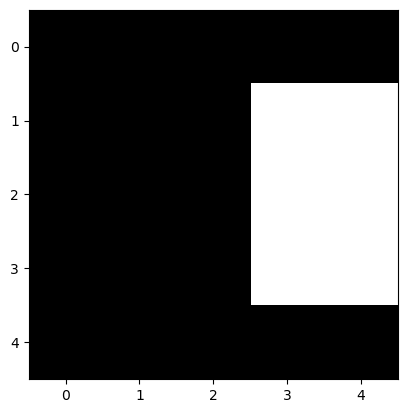

In [79]:
img = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1],
    [0, 0, 0, 1, 1],
    [0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0]
]).astype(float)
plt.imshow(img, cmap='gray')

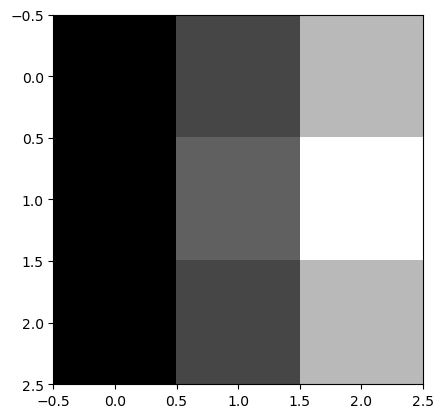

In [81]:
plt.imshow(convolution(img, gaussian_kernel(3, sigma=1)), cmap='gray')

dtype('int32')